LOADING CLEANED TITANIC DATASET
Dataset loaded from: analytics\data\titanic_clean.csv
Dataset shape: (889, 13)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,no,True



FEATURES AND TARGET
Features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

Target: survived

Target distribution:
survived
0    549
1    340
Name: count, dtype: int64

Target percentage:
survived
0    61.75
1    38.25
Name: proportion, dtype: float64

TASK 7 — STRATIFIED TRAIN / TEST SPLIT
Training rows: 711
Testing rows : 178

Training target distribution:
survived
0    0.617
1    0.383
Name: proportion, dtype: float64

Testing target distribution:
survived
0    0.618
1    0.382
Name: proportion, dtype: float64

TASK 8 — PREPROCESSING PIPELINE

TASK 9 & 10 — CLASSIFICATION MODELS

Training: Logistic Regression

Training: Decision Tree

Training: Random Forest

CLASSIFICATION RESULTS


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.8090,0.8148,0.6471,0.7213,0.8560
2,Random Forest,0.8202,0.7812,0.7353,0.7576,0.8179



CONFUSION MATRICES

Logistic Regression
[[97 13]
 [21 47]]


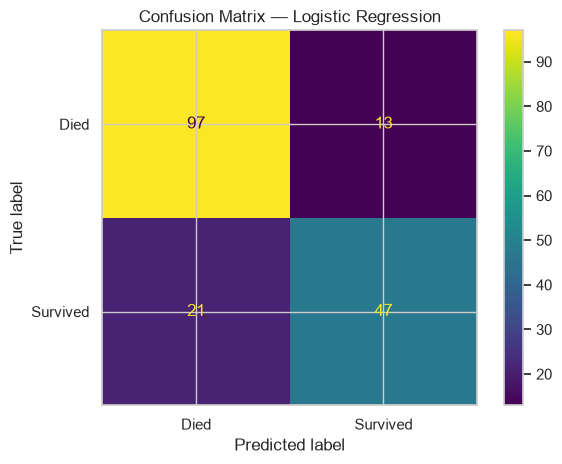


Decision Tree
[[100  10]
 [ 24  44]]


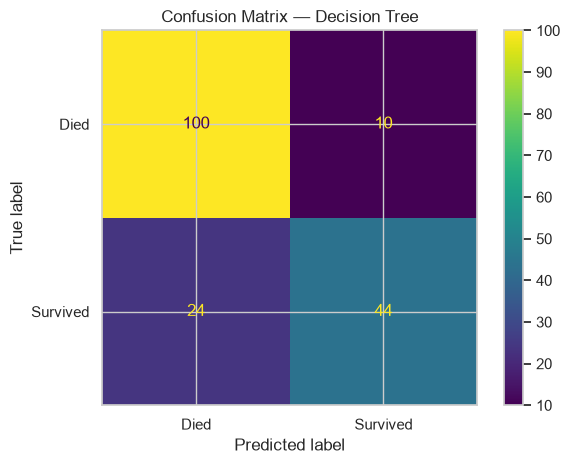


Random Forest
[[96 14]
 [18 50]]


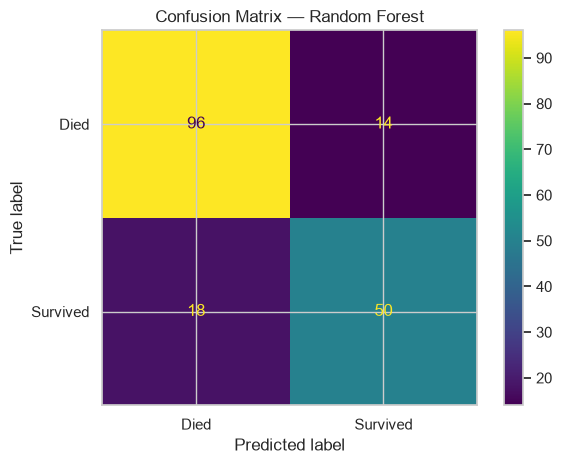


ROC CURVES


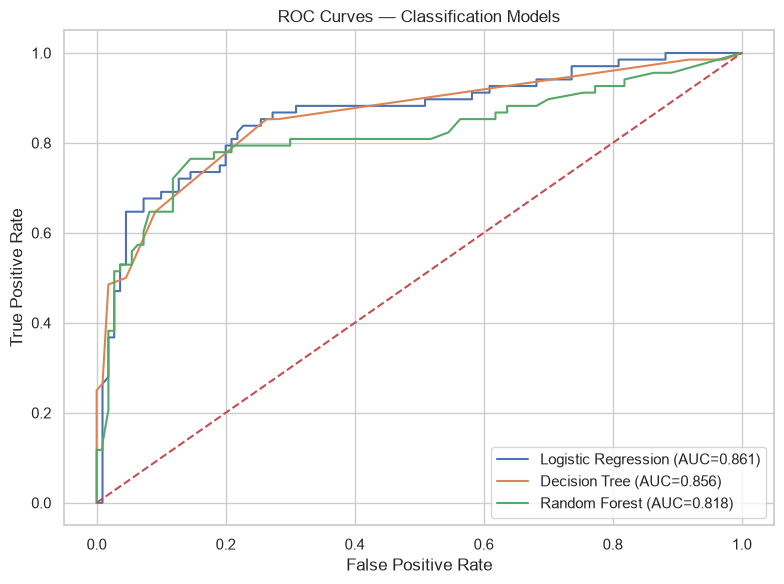


RANDOM FOREST OOB SCORE
OOB Score: 0.8017

DECISION TREE VISUALIZATION


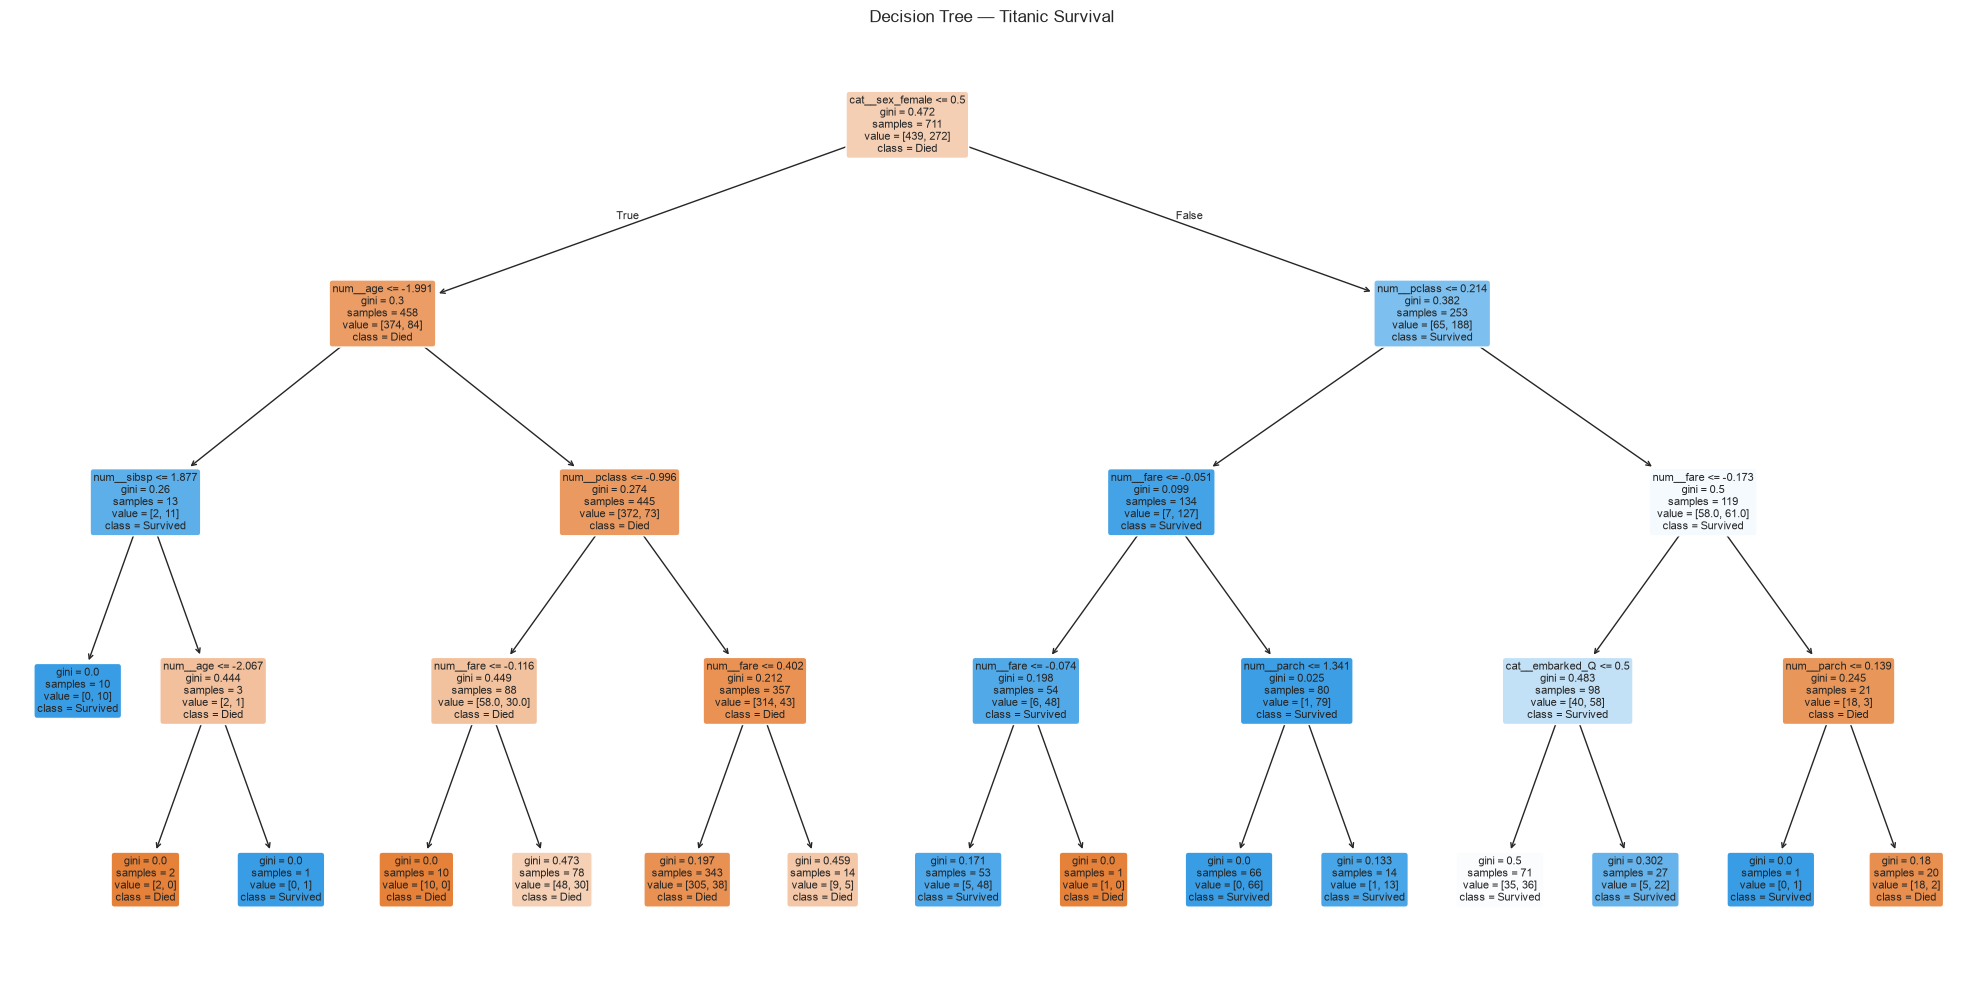


TASK 11 — IMBALANCE HANDLING
Training data after preprocessing: (711, 10)
Testing data after preprocessing : (178, 10)

Original training class distribution:
survived
0    439
1    272
Name: count, dtype: int64

After SMOTE:
survived
1    439
0    439
Name: count, dtype: int64

IMBALANCE HANDLING RESULTS


,Strategy,Precision,Recall,F1 Score
0,Baseline,0.7812,0.7353,0.7576
1,Balanced Class Weight,0.7391,0.7500,0.7445
2,SMOTE,0.7460,0.6912,0.7176



TASK 12 — RANDOM FOREST HYPERPARAMETER TUNING

Best Hyperparameters:
{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 50}

Best Cross-Validation F1: 0.7403

TUNED RANDOM FOREST TEST RESULTS
Accuracy: 0.8315
Precision: 0.8654
Recall: 0.6618
F1 Score: 0.7500
ROC-AUC: 0.8397

Tuned Random Forest OOB Score: 0.8172

Tuned Random Forest Confusion Matrix:
[[103   7]
 [ 23  45]]


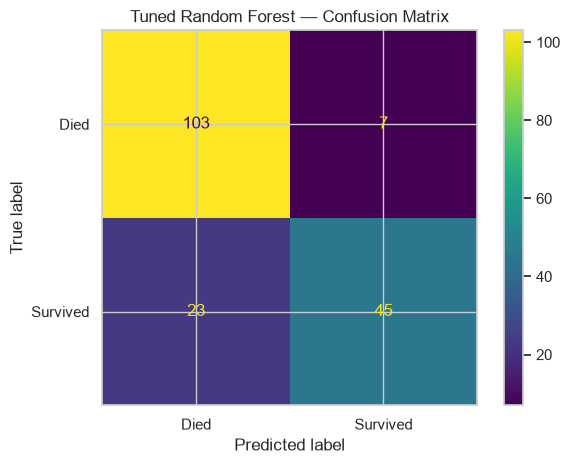


GRID SEARCH RESULTS


,params,mean_test_score,std_test_score,rank_test_score
6,"{'classifier__max_depth': 5, 'classifier__max_...",0.740250,0.040928,1
4,"{'classifier__max_depth': 5, 'classifier__max_...",0.740250,0.040928,1
7,"{'classifier__max_depth': 5, 'classifier__max_...",0.737000,0.038087,3
5,"{'classifier__max_depth': 5, 'classifier__max_...",0.737000,0.038087,3
3,"{'classifier__max_depth': 3, 'classifier__max_...",0.736788,0.028155,5
1,"{'classifier__max_depth': 3, 'classifier__max_...",0.736788,0.028155,5
2,"{'classifier__max_depth': 3, 'classifier__max_...",0.735556,0.026339,7
0,"{'classifier__max_depth': 3, 'classifier__max_...",0.735556,0.026339,7
9,"{'classifier__max_depth': 10, 'classifier__max...",0.732267,0.049614,9
11,"{'classifier__max_depth': 10, 'classifier__max...",0.732267,0.049614,9



TASK 13 — FARE REGRESSION
Regression dataset shape: (889, 7)

FARE REGRESSION RESULTS


,Metric,Value
0,MAE,21.1386
1,RMSE,41.7465
2,R²,0.3468
3,Adjusted R²,0.3118


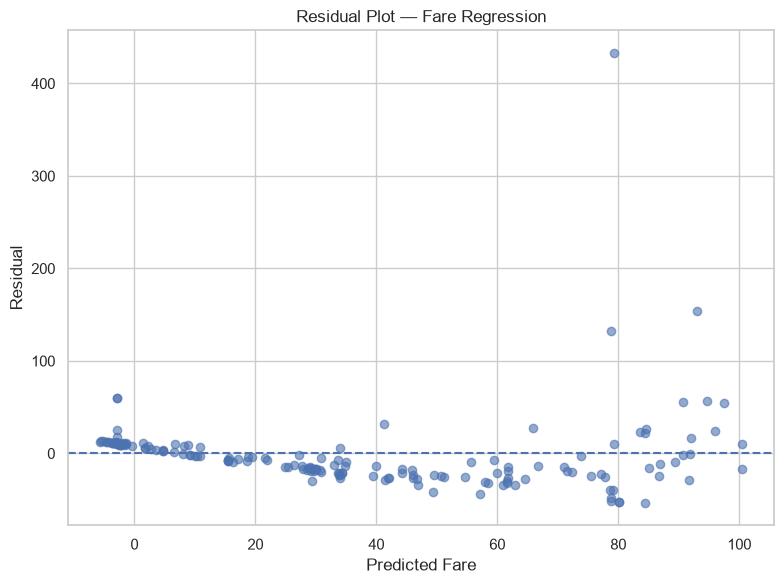

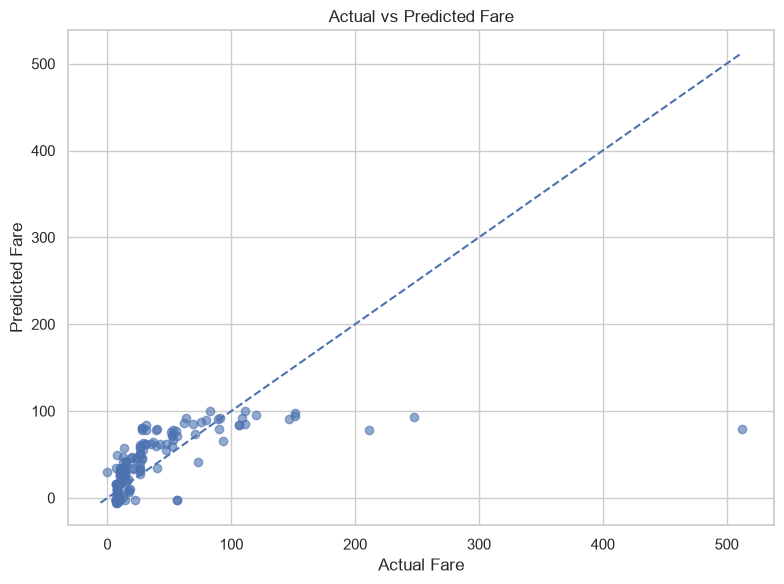


TASK 15 — SAVING MODEL ARTIFACTS
Best classifier saved to:
analytics\models\best_titanic_classifier.joblib

Regression pipeline saved to:
analytics\models\fare_regression_pipeline.joblib

RELOADED PIPELINE RAW INPUT TEST
Input:


,pclass,sex,age,sibsp,parch,fare,embarked
0,1,female,28.0,0,0,100.0,S


Predicted class: 1
Predicted survival probability: 0.9521

PASS: Saved and reloaded classification pipeline successfully accepted raw input.

MODULE 2 MODELING SUMMARY

Classification models:
- Logistic Regression
- Decision Tree
- Random Forest

Imbalance strategies:
- Baseline
- Balanced class weights
- SMOTE on training data

Hyperparameter tuning:
- GridSearchCV
- 5-fold cross-validation
- F1 scoring

Regression:
- Linear Regression
- MAE
- RMSE
- R²
- Adjusted R²
- Residual analysis

Saved artifacts:
- analytics\models\best_titanic_classifier.joblib
- analytics\models\fare_regression_pipeline.joblib

MODULE 2 MODELING COMPLETED SUCCESSFULLY


In [ ]:

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import (
    LogisticRegression,
    LinearRegression
)

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.ensemble import (
    RandomForestClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from imblearn.over_sampling import SMOTE


warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")


# ============================================================
# 2. CREATE DIRECTORIES
# ============================================================

DATA_DIR = os.path.join(
    "analytics",
    "data"
)

OUTPUT_DIR = os.path.join(
    "analytics",
    "outputs"
)

MODEL_DIR = os.path.join(
    "analytics",
    "models"
)

os.makedirs(
    DATA_DIR,
    exist_ok=True
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)


# ============================================================
# 3. LOAD CLEANED DATASET
# ============================================================

print("=" * 70)
print("LOADING CLEANED TITANIC DATASET")
print("=" * 70)

CLEAN_DATA_PATH = os.path.join(
    DATA_DIR,
    "titanic_clean.csv"
)

if not os.path.exists(CLEAN_DATA_PATH):

    raise FileNotFoundError(
        f"""
Cleaned dataset was not found:

{CLEAN_DATA_PATH}

Run 01_EDA.ipynb successfully first.
"""
    )


df = pd.read_csv(
    CLEAN_DATA_PATH
)

print(
    f"Dataset loaded from: {CLEAN_DATA_PATH}"
)

print(
    f"Dataset shape: {df.shape}"
)

display(
    df.head()
)


# ============================================================
# 4. DEFINE FEATURES AND TARGET
# ============================================================

print("\n" + "=" * 70)
print("FEATURES AND TARGET")
print("=" * 70)

features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

target = "survived"


X = df[features].copy()

y = df[target].copy()


print(
    "Features:"
)

print(
    features
)

print(
    f"\nTarget: {target}"
)

print(
    "\nTarget distribution:"
)

print(
    y.value_counts()
)

print(
    "\nTarget percentage:"
)

print(
    (y.value_counts(normalize=True) * 100).round(2)
)


# ============================================================
# 5. TRAIN / TEST SPLIT
# ============================================================

print("\n" + "=" * 70)
print("TASK 7 — STRATIFIED TRAIN / TEST SPLIT")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(
    f"Training rows: {len(X_train)}"
)

print(
    f"Testing rows : {len(X_test)}"
)

print(
    "\nTraining target distribution:"
)

print(
    y_train.value_counts(normalize=True).round(3)
)

print(
    "\nTesting target distribution:"
)

print(
    y_test.value_counts(normalize=True).round(3)
)


# ============================================================
# 6. DEFINE PREPROCESSING
# ============================================================

print("\n" + "=" * 70)
print("TASK 8 — PREPROCESSING PIPELINE")
print("=" * 70)

numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]


numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)


# ============================================================
# 7. CLASSIFICATION MODELS
# ============================================================

print("\n" + "=" * 70)
print("TASK 9 & 10 — CLASSIFICATION MODELS")
print("=" * 70)


classifiers = {

    "Logistic Regression":
        LogisticRegression(
            random_state=42,
            max_iter=1000
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=4,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            oob_score=True
        )
}


classification_results = []

trained_pipelines = {}


# ============================================================
# 8. TRAIN AND EVALUATE CLASSIFIERS
# ============================================================

for name, classifier in classifiers.items():

    print(
        f"\nTraining: {name}"
    )

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "classifier",
                classifier
            )
        ]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    y_pred = pipeline.predict(
        X_test
    )

    y_probability = pipeline.predict_proba(
        X_test
    )[:, 1]

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_test,
        y_probability
    )

    classification_results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "ROC-AUC": auc
    })

    trained_pipelines[name] = pipeline


# ============================================================
# 9. CLASSIFICATION RESULTS TABLE
# ============================================================

classification_results_df = pd.DataFrame(
    classification_results
)

print("\n" + "=" * 70)
print("CLASSIFICATION RESULTS")
print("=" * 70)

display(
    classification_results_df.round(4)
)


classification_results_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "classification_results.csv"
    ),
    index=False
)


# ============================================================
# 10. CONFUSION MATRICES
# ============================================================

print("\n" + "=" * 70)
print("CONFUSION MATRICES")
print("=" * 70)


for name, pipeline in trained_pipelines.items():

    predictions = pipeline.predict(
        X_test
    )

    cm = confusion_matrix(
        y_test,
        predictions
    )

    print(
        f"\n{name}"
    )

    print(
        cm
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Died",
            "Survived"
        ]
    )

    disp.plot()

    plt.title(
        f"Confusion Matrix — {name}"
    )

    plt.tight_layout()

    safe_name = (
        name
        .lower()
        .replace(" ", "_")
    )

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"confusion_matrix_{safe_name}.png"
        ),
        dpi=300
    )

    plt.show()


# ============================================================
# 11. ROC CURVES
# ============================================================

print("\n" + "=" * 70)
print("ROC CURVES")
print("=" * 70)


plt.figure(figsize=(8, 6))


for name, pipeline in trained_pipelines.items():

    probabilities = pipeline.predict_proba(
        X_test
    )[:, 1]

    fpr, tpr, thresholds = roc_curve(
        y_test,
        probabilities
    )

    auc_value = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_value:.3f})"
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curves — Classification Models"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "roc_curves.png"
    ),
    dpi=300
)

plt.show()


# ============================================================
# 12. RANDOM FOREST OOB SCORE
# ============================================================

rf_pipeline = trained_pipelines[
    "Random Forest"
]

rf_model = rf_pipeline.named_steps[
    "classifier"
]

print("\n" + "=" * 70)
print("RANDOM FOREST OOB SCORE")
print("=" * 70)

print(
    f"OOB Score: {rf_model.oob_score_:.4f}"
)


# ============================================================
# 13. DECISION TREE VISUALIZATION
# ============================================================

print("\n" + "=" * 70)
print("DECISION TREE VISUALIZATION")
print("=" * 70)


dt_pipeline = trained_pipelines[
    "Decision Tree"
]

dt_model = dt_pipeline.named_steps[
    "classifier"
]

dt_preprocessor = dt_pipeline.named_steps[
    "preprocessor"
]


try:

    feature_names = (
        dt_preprocessor
        .get_feature_names_out()
    )

except Exception:

    feature_names = None


plt.figure(
    figsize=(20, 10)
)

plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=[
        "Died",
        "Survived"
    ],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title(
    "Decision Tree — Titanic Survival"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "decision_tree.png"
    ),
    dpi=300
)

plt.show()


# ============================================================
# 14. TASK 11 — IMBALANCE HANDLING
# ============================================================

print("\n" + "=" * 70)
print("TASK 11 — IMBALANCE HANDLING")
print("=" * 70)


# Fit preprocessing ONLY on training data.

X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)


print(
    "Training data after preprocessing:",
    X_train_processed.shape
)

print(
    "Testing data after preprocessing :",
    X_test_processed.shape
)


# ------------------------------------------------------------
# BASELINE RANDOM FOREST
# ------------------------------------------------------------

baseline_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

baseline_rf.fit(
    X_train_processed,
    y_train
)

baseline_predictions = baseline_rf.predict(
    X_test_processed
)


# ------------------------------------------------------------
# CLASS-WEIGHT BALANCED RANDOM FOREST
# ------------------------------------------------------------

balanced_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

balanced_rf.fit(
    X_train_processed,
    y_train
)

balanced_predictions = balanced_rf.predict(
    X_test_processed
)


# ------------------------------------------------------------
# SMOTE
# ------------------------------------------------------------

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = (
    smote.fit_resample(
        X_train_processed,
        y_train
    )
)


print(
    "\nOriginal training class distribution:"
)

print(
    y_train.value_counts()
)


print(
    "\nAfter SMOTE:"
)

print(
    pd.Series(y_train_smote)
    .value_counts()
)


smote_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

smote_rf.fit(
    X_train_smote,
    y_train_smote
)

smote_predictions = smote_rf.predict(
    X_test_processed
)


# ============================================================
# 15. IMBALANCE RESULTS
# ============================================================

imbalance_models = {

    "Baseline":
        baseline_predictions,

    "Balanced Class Weight":
        balanced_predictions,

    "SMOTE":
        smote_predictions
}


imbalance_results = []


for name, predictions in imbalance_models.items():

    imbalance_results.append({

        "Strategy": name,

        "Precision":
            precision_score(
                y_test,
                predictions,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_test,
                predictions,
                zero_division=0
            ),

        "F1 Score":
            f1_score(
                y_test,
                predictions,
                zero_division=0
            )
    })


imbalance_results_df = pd.DataFrame(
    imbalance_results
)


print("\n" + "=" * 70)
print("IMBALANCE HANDLING RESULTS")
print("=" * 70)

display(
    imbalance_results_df.round(4)
)


imbalance_results_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "imbalance_results.csv"
    ),
    index=False
)


# ============================================================
# 16. TASK 12 — HYPERPARAMETER TUNING
# ============================================================

print("\n" + "=" * 70)
print("TASK 12 — RANDOM FOREST HYPERPARAMETER TUNING")
print("=" * 70)


# IMPORTANT:
# The preprocessor is inside the pipeline.
# Therefore each GridSearchCV fold fits preprocessing
# only on that fold's training portion.

rf_pipeline_for_tuning = Pipeline(
    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            RandomForestClassifier(
                oob_score=True,
                random_state=42
            )
        )
    ]
)


param_grid = {

    "classifier__n_estimators":
        [50, 100],

    "classifier__max_depth":
        [3, 5, 10],

    "classifier__max_features":
        ["sqrt", "log2"]
}


grid_search = GridSearchCV(

    estimator=rf_pipeline_for_tuning,

    param_grid=param_grid,

    cv=5,

    scoring="f1",

    n_jobs=-1,

    return_train_score=True
)


grid_search.fit(
    X_train,
    y_train
)


print(
    "\nBest Hyperparameters:"
)

print(
    grid_search.best_params_
)


print(
    f"\nBest Cross-Validation F1: "
    f"{grid_search.best_score_:.4f}"
)


best_pipeline = (
    grid_search.best_estimator_
)


# ============================================================
# 17. EVALUATE TUNED MODEL ON TEST SET
# ============================================================

best_predictions = best_pipeline.predict(
    X_test
)

best_probabilities = (
    best_pipeline.predict_proba(
        X_test
    )[:, 1]
)


tuned_results = {

    "Accuracy":
        accuracy_score(
            y_test,
            best_predictions
        ),

    "Precision":
        precision_score(
            y_test,
            best_predictions,
            zero_division=0
        ),

    "Recall":
        recall_score(
            y_test,
            best_predictions,
            zero_division=0
        ),

    "F1 Score":
        f1_score(
            y_test,
            best_predictions,
            zero_division=0
        ),

    "ROC-AUC":
        roc_auc_score(
            y_test,
            best_probabilities
        )
}


print("\n" + "=" * 70)
print("TUNED RANDOM FOREST TEST RESULTS")
print("=" * 70)

for metric, value in tuned_results.items():

    print(
        f"{metric}: {value:.4f}"
    )


# ============================================================
# 18. TUNED MODEL OOB SCORE
# ============================================================

tuned_rf = (
    best_pipeline
    .named_steps["classifier"]
)


print(
    f"\nTuned Random Forest OOB Score: "
    f"{tuned_rf.oob_score_:.4f}"
)


# ============================================================
# 19. TUNED MODEL CONFUSION MATRIX
# ============================================================

tuned_cm = confusion_matrix(
    y_test,
    best_predictions
)


print(
    "\nTuned Random Forest Confusion Matrix:"
)

print(
    tuned_cm
)


ConfusionMatrixDisplay(
    confusion_matrix=tuned_cm,
    display_labels=[
        "Died",
        "Survived"
    ]
).plot()


plt.title(
    "Tuned Random Forest — Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "tuned_random_forest_confusion_matrix.png"
    ),
    dpi=300
)

plt.show()


# ============================================================
# 20. GRID SEARCH RESULTS
# ============================================================

grid_results = pd.DataFrame(
    grid_search.cv_results_
)

grid_results = grid_results[
    [
        "params",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values(
    "rank_test_score"
)


print("\n" + "=" * 70)
print("GRID SEARCH RESULTS")
print("=" * 70)

display(
    grid_results.head(10)
)


grid_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "grid_search_results.csv"
    ),
    index=False
)


# ============================================================
# 21. TASK 13 — FARE REGRESSION
# ============================================================

print("\n" + "=" * 70)
print("TASK 13 — FARE REGRESSION")
print("=" * 70)


# We predict fare, so fare must NOT be included as a feature.

regression_features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked"
]


regression_df = df[
    regression_features + ["fare"]
].copy()


regression_df = regression_df.dropna(
    subset=["fare"]
)


X_reg = regression_df[
    regression_features
].copy()


y_reg = regression_df[
    "fare"
].copy()


print(
    f"Regression dataset shape: "
    f"{regression_df.shape}"
)


# ============================================================
# 22. REGRESSION TRAIN / TEST SPLIT
# ============================================================

X_reg_train, X_reg_test, y_reg_train, y_reg_test = (
    train_test_split(
        X_reg,
        y_reg,
        test_size=0.20,
        random_state=42
    )
)


# ============================================================
# 23. REGRESSION PREPROCESSING
# ============================================================

reg_numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch"
]

reg_categorical_features = [
    "sex",
    "embarked"
]


reg_numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


reg_categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


reg_preprocessor = ColumnTransformer(
    transformers=[

        (
            "num",
            reg_numeric_transformer,
            reg_numeric_features
        ),

        (
            "cat",
            reg_categorical_transformer,
            reg_categorical_features
        )
    ]
)


# ============================================================
# 24. LINEAR REGRESSION PIPELINE
# ============================================================

regression_pipeline = Pipeline(
    steps=[

        (
            "preprocessor",
            reg_preprocessor
        ),

        (
            "regressor",
            LinearRegression()
        )
    ]
)


regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)


y_reg_pred = regression_pipeline.predict(
    X_reg_test
)


# ============================================================
# 25. REGRESSION METRICS
# ============================================================

mae = mean_absolute_error(
    y_reg_test,
    y_reg_pred
)


rmse = np.sqrt(
    mean_squared_error(
        y_reg_test,
        y_reg_pred
    )
)


r2 = r2_score(
    y_reg_test,
    y_reg_pred
)


# Determine the number of transformed predictors.

reg_transformed_train = (
    regression_pipeline
    .named_steps["preprocessor"]
    .transform(X_reg_train)
)


p = reg_transformed_train.shape[1]

n = len(y_reg_test)


if n > p + 1:

    adjusted_r2 = (
        1
        -
        (
            (1 - r2)
            *
            (n - 1)
            /
            (n - p - 1)
        )
    )

else:

    adjusted_r2 = np.nan


regression_results = pd.DataFrame({

    "Metric": [
        "MAE",
        "RMSE",
        "R²",
        "Adjusted R²"
    ],

    "Value": [
        mae,
        rmse,
        r2,
        adjusted_r2
    ]
})


print("\n" + "=" * 70)
print("FARE REGRESSION RESULTS")
print("=" * 70)

display(
    regression_results.round(4)
)


regression_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "regression_results.csv"
    ),
    index=False
)


# ============================================================
# 26. REGRESSION RESIDUAL ANALYSIS
# ============================================================

residuals = (
    y_reg_test
    -
    y_reg_pred
)


plt.figure(
    figsize=(8, 6)
)


plt.scatter(
    y_reg_pred,
    residuals,
    alpha=0.6
)


plt.axhline(
    y=0,
    linestyle="--"
)


plt.xlabel(
    "Predicted Fare"
)


plt.ylabel(
    "Residual"
)


plt.title(
    "Residual Plot — Fare Regression"
)


plt.tight_layout()


plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "fare_regression_residuals.png"
    ),
    dpi=300
)


plt.show()


# ============================================================
# 27. ACTUAL VS PREDICTED FARE
# ============================================================

plt.figure(
    figsize=(8, 6)
)


plt.scatter(
    y_reg_test,
    y_reg_pred,
    alpha=0.6
)


min_value = min(
    y_reg_test.min(),
    y_reg_pred.min()
)

max_value = max(
    y_reg_test.max(),
    y_reg_pred.max()
)


plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)


plt.xlabel(
    "Actual Fare"
)


plt.ylabel(
    "Predicted Fare"
)


plt.title(
    "Actual vs Predicted Fare"
)


plt.tight_layout()


plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "actual_vs_predicted_fare.png"
    ),
    dpi=300
)


plt.show()


# ============================================================
# 28. SAVE COMPLETE CLASSIFICATION PIPELINE
# ============================================================

print("\n" + "=" * 70)
print("TASK 15 — SAVING MODEL ARTIFACTS")
print("=" * 70)


BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_titanic_classifier.joblib"
)


joblib.dump(
    best_pipeline,
    BEST_MODEL_PATH
)


print(
    f"Best classifier saved to:"
    f"\n{BEST_MODEL_PATH}"
)


# ============================================================
# 29. SAVE REGRESSION PIPELINE
# ============================================================

REGRESSION_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "fare_regression_pipeline.joblib"
)


joblib.dump(
    regression_pipeline,
    REGRESSION_MODEL_PATH
)


print(
    f"\nRegression pipeline saved to:"
    f"\n{REGRESSION_MODEL_PATH}"
)


# ============================================================
# 30. RELOAD CLASSIFICATION PIPELINE
# ============================================================

reloaded_classifier = joblib.load(
    BEST_MODEL_PATH
)


# ============================================================
# 31. RAW INPUT PREDICTION TEST
# ============================================================

sample_raw = pd.DataFrame([{

    "pclass": 1,

    "sex": "female",

    "age": 28.0,

    "sibsp": 0,

    "parch": 0,

    "fare": 100.0,

    "embarked": "S"
}])


sample_prediction = (
    reloaded_classifier
    .predict(sample_raw)
)


sample_probability = (
    reloaded_classifier
    .predict_proba(sample_raw)[:, 1]
)


print("\n" + "=" * 70)
print("RELOADED PIPELINE RAW INPUT TEST")
print("=" * 70)


print(
    "Input:"
)

display(
    sample_raw
)


print(
    f"Predicted class: "
    f"{sample_prediction[0]}"
)


print(
    f"Predicted survival probability: "
    f"{sample_probability[0]:.4f}"
)


# ============================================================
# 32. VERIFY SAVED MODEL CAN PREDICT
# ============================================================

assert sample_prediction[0] in [
    0,
    1
]


print(
    "\nPASS: Saved and reloaded classification "
    "pipeline successfully accepted raw input."
)


# ============================================================
# 33. FINAL MODEL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("MODULE 2 MODELING SUMMARY")
print("=" * 70)


print(
    f"""
Classification models:
- Logistic Regression
- Decision Tree
- Random Forest

Imbalance strategies:
- Baseline
- Balanced class weights
- SMOTE on training data

Hyperparameter tuning:
- GridSearchCV
- 5-fold cross-validation
- F1 scoring

Regression:
- Linear Regression
- MAE
- RMSE
- R²
- Adjusted R²
- Residual analysis

Saved artifacts:
- {BEST_MODEL_PATH}
- {REGRESSION_MODEL_PATH}
"""
)


# ============================================================
# 34. FINAL SUCCESS MESSAGE
# ============================================================

print("=" * 70)
print("MODULE 2 MODELING COMPLETED SUCCESSFULLY")
print("=" * 70)